In [1]:
#This code block contains the trainng and testing of random forest model

In [22]:
pip install pandas scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split

In [24]:
file = "../Dataset/final_sdb_dataset_clean.csv"
df = pd.read_csv(file)
df_shallow = df[(df['depth'] >= 0) & (df['depth'] <= 30)].copy()


In [25]:
print(f"Original rows: {len(df)} | Rows after filtering (depth <= 30): {len(df_shallow)}")

Original rows: 11676 | Rows after filtering (depth <= 30): 4548


In [26]:
df_shallow['log_blue'] = np.log(df_shallow['blue_band'] + 1e-6)
df_shallow['log_green'] = np.log(df_shallow['green_band'] + 1e-6)
df_shallow['blue_green_ratio'] = df_shallow['blue_band'] / (df_shallow['green_band'] + 1e-6)
df_shallow['ndwi'] = (df_shallow['green_band'] - df_shallow['blue_band']) / (df_shallow['green_band'] + df_shallow['blue_band'] + 1e-6)

In [30]:
df_arabian_sea = df_shallow[(df_shallow['longitude'] > 48) & (df_shallow['longitude'] < 60)].copy()
df_strait_of_hormuz = df_shallow[(df_shallow['longitude'] > 65) & (df_shallow['longitude'] < 70)].copy()
df_bay_of_bengal = df_shallow[df_shallow['longitude'] >= 70].copy()

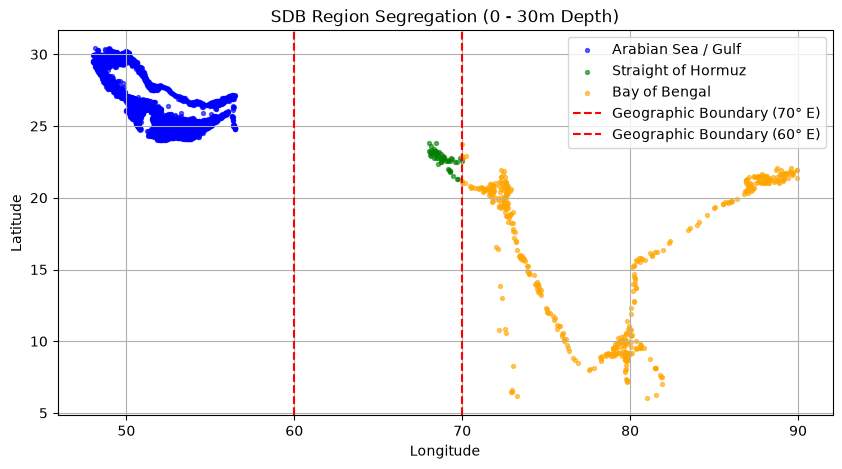

In [33]:
plt.figure(figsize=(10, 5))
plt.scatter(df_arabian_sea['longitude'], df_arabian_sea['latitude'], c='blue', label='Arabian Sea / Gulf', s=8, alpha=0.6)
plt.scatter(df_strait_of_hormuz['longitude'], df_strait_of_hormuz['latitude'], c='green', label='Straight of Hormuz', s=8, alpha=0.6)
plt.scatter(df_bay_of_bengal['longitude'], df_bay_of_bengal['latitude'], c='orange', label='Bay of Bengal', s=8, alpha=0.6)
plt.axvline(x=70, color='red', linestyle='--', label='Geographic Boundary (70° E)')
plt.axvline(x=60, color='red', linestyle='--', label='Geographic Boundary (60° E)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('SDB Region Segregation (0 - 30m Depth)')
plt.legend()
plt.grid(True)
plt.show()

In [34]:
for name, data in regions.items():
    if len(data) < 5:
        print(f"Skipping {name} - Not enough samples ({len(data)} rows).")
        continue

    X = data[feature_cols]
    y = data['depth']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    
    y_pred = rf.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    print(f"=== {name} ===")
    print(f"Sample Count: {len(data)}")
    print(f"R² Score:     {r2:.4f}")
    print(f"RMSE:         {rmse:.4f}\n")

NameError: name 'regions' is not defined

In [10]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

In [11]:
print("\n--- Model Evaluation (For Depth <= 30) ---")
print(f"RMSE: {rmse}")
print(f"Mean Absolute Error: {mae:.4f} (Average prediction error)")
print(f"R² Score: {r2:.4f} (Closer to 1.0 is better)")


--- Model Evaluation (For Depth <= 30) ---
RMSE: 6.3776284155769
Mean Absolute Error: 4.9820 (Average prediction error)
R² Score: 0.4836 (Closer to 1.0 is better)
